In [1]:
import os
import sys

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..', '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [2]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.models.efficient_transformer import EfficientNetTransformer
import random

## 1. Load trained model

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = 'cpu'
MODEL_PATH = r"..\..\models\checkpoints\efficient_transformer\best_model_efficient_transformer.pth"
VIDEO_PATH = r"..\..\data\training_dataset\test\brush_hair\brush_hair_015.mp4"

print(f'Device      :{DEVICE}')
print(f'Model path  :{MODEL_PATH}')
print(f'Video path  :{VIDEO_PATH}')

Device      :cpu
Model path  :..\..\models\checkpoints\efficient_transformer\best_model_efficient_transformer.pth
Video path  :..\..\data\training_dataset\test\brush_hair\brush_hair_015.mp4


In [4]:
# --- Initiate model and load checkpoints ---
model = EfficientNetTransformer(
    num_classes=6,
    d_model = 512,
    nhead = 8,
    num_layers=2,
    dropout = 0.5
    
).to(DEVICE)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
if 'state_dict' in checkpoint:
    model.load_state_dict(checkpoint['state_dict'])
else:
    model.load_state_dict(checkpoint)

# --- Turn to evaluation mode ---
model.eval()
print("Model loaded successfully!")

Initializing EfficientNet-B0 backbone...
Model loaded successfully!


## 2. Model analysis

### 2.1. CNN module

#### 2.1.1. Tool definition

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.handle = target_layer.register_forward_hook(self.save_activation)

    def save_activation(self, module, input, output):
        self.activations = output

    def close(self):
        self.handle.remove()

    def __call__(self, x, class_idx=None):
        logits = self.model(x)
        if self.activations is None:
            raise ValueError("Chưa bắt được activation. Kiểm tra lại target_layer.")
            
        self.activations.retain_grad()
        
        self.model.zero_grad()
        if class_idx is None:
            class_idx = torch.argmax(logits)
        
        score = logits[0, class_idx]
        score.backward(retain_graph=True) 
        
        self.gradients = self.activations.grad
        
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)
        cam_avg = torch.mean(cam, dim=0)
        cam_avg = cam_avg - torch.min(cam_avg)
        cam_avg = cam_avg / (torch.max(cam_avg) + 1e-8)
        
        return cam_avg.data.cpu().numpy()[0]

In [ ]:
class VideoAnalyzer:
    def __init__(self, model, target_layer, device='cuda'):
        self.model = model
        self.target_layer = target_layer
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.model.eval()
        
        self.activations = None
        self.gradients = None
        self.handle = self.target_layer.register_forward_hook(self.save_activation)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def _get_gradcam_maps(self, input_tensor, class_idx=None):
        """Tính Grad-CAM cho TẤT CẢ các frames trong tensor"""
        self.activations = None
        self.gradients = None
        
        logits = self.model(input_tensor)
        
        self.activations.retain_grad()
        
        if class_idx is None:
            class_idx = torch.argmax(logits)
        
        self.model.zero_grad()
        score = logits[0, class_idx]
        score.backward(retain_graph=True)
        
        grads = self.activations.grad
        acts = self.activations
        
        weights = torch.mean(grads, dim=[2, 3], keepdim=True)
        cam = torch.sum(weights * acts, dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)
        
        return cam.detach().cpu().numpy()

    def _denormalize(self, img_tensor):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        
        img = img_tensor.detach().permute(1, 2, 0).cpu().numpy()
        
        img = (img * std + mean)
        return np.clip(img, 0, 1)

    def analyze(self, video_path, num_random_frames=4):
        cap = cv2.VideoCapture(video_path)
        all_frames = []
        while True:
            ret, frame = cap.read()
            if not ret: break
            all_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cap.release()

        indices = sorted(random.sample(range(len(all_frames)), num_random_frames))
        
        processed_list = []
        for idx in indices:
            img = cv2.resize(all_frames[idx], (224, 224))
            img = img.astype(np.float32) / 255.0
            img = (img - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
            processed_list.append(img)
        
        input_tensor = torch.tensor(np.array(processed_list)).permute(0, 3, 1, 2).unsqueeze(0).to(self.device).float()
        input_tensor.requires_grad = True

        cam_maps = self._get_gradcam_maps(input_tensor)

        fig, axes = plt.subplots(2, num_random_frames, figsize=(16, 8))
        
        for i in range(num_random_frames):
            real_img = self._denormalize(input_tensor[0, i])
            axes[0, i].imshow(real_img)
            axes[0, i].set_title(f"Frame {indices[i]}")
            axes[0, i].axis('off')

            heatmap = cam_maps[i, 0]
            heatmap_resized = cv2.resize(heatmap, (224, 224))
            
            heatmap_resized = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() - heatmap_resized.min() + 1e-8)
            heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
            heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
            
            overlay = cv2.addWeighted(real_img, 0.6, heatmap_color, 0.4, 0)
            
            axes[1, i].imshow(overlay)
            axes[1, i].set_title(f"Model Vision {i+1}")
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.show()

In [7]:
target_layer = model.backbone.features[-1]
analyzer = VideoAnalyzer(model, target_layer)

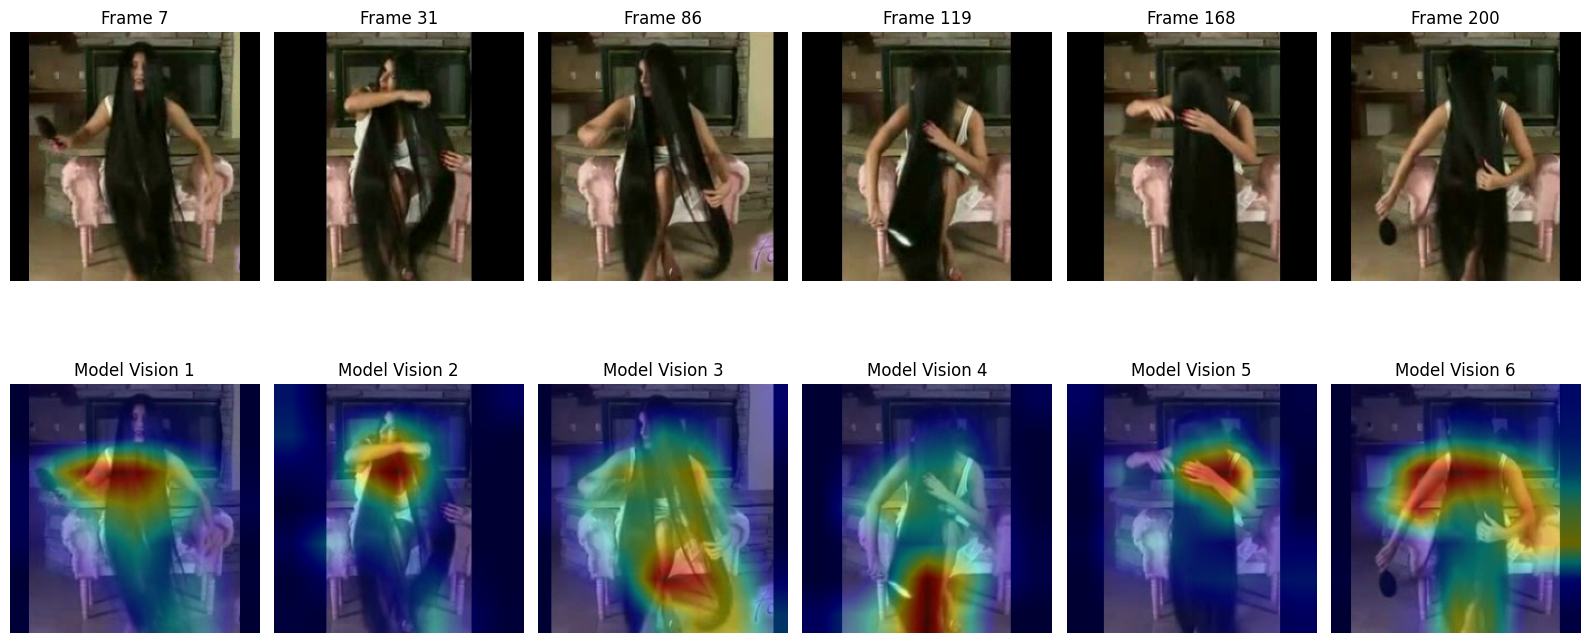

In [8]:
analyzer.analyze(VIDEO_PATH, num_random_frames=6)

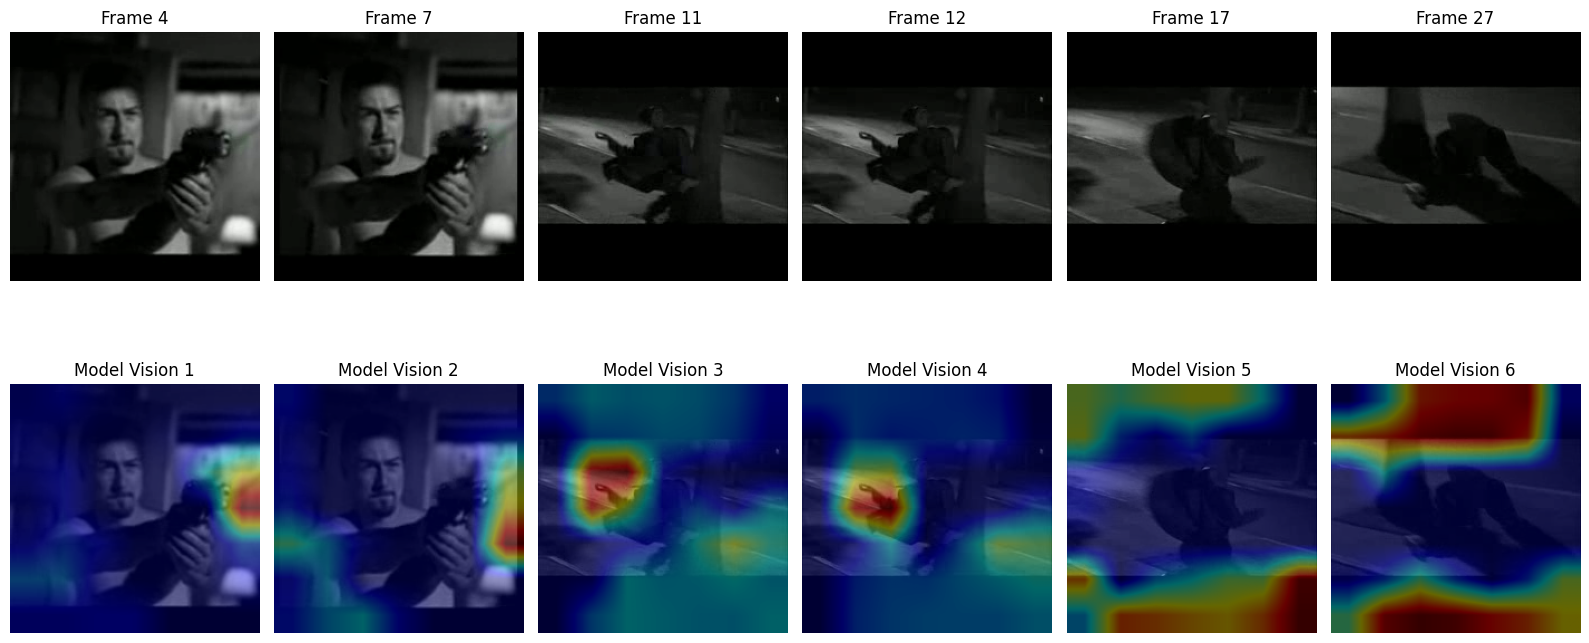

In [9]:
path_2 = r'..\..\data\training_dataset\test\fall_floor\fall_floor_004.mp4'
analyzer.analyze(path_2, num_random_frames=6)